# **Business Analytics**



## Introduction

Unpredictability of booking cancellations is a significant issue faced by many hotels since it can affect staff members and plan pricing. With no understanding of the influential factors of booking cancellations, hotels may struggle to implement effective management strategies.



###Problem Definition

The problem addressed in this analysis is the identification and prediction of booking cancellations by determining which characteristics are associated with a higher chance of cancellation. Additionally, these characteristics will be investigated as to their relation to booking cancellation forecasting.







###Business Questions:

1. Which booking characteristics are mostly associated with hotel booking cancellations?

2. Can these characteristics be used to predict whether a booking will be canceled?


###Objectives:

• Explore patterns in hotel booking demand using historical reservation data.

• Identify variables that influence the likelihood of booking cancellations.

• Apply statistical analysis and machine learning techniques to predict cancellation behavior.

• Generate supportive results for hotel management to reduce cancellation-related losses.

##Data Acquisition and Preparation

The dataset used in this analysis is of hotel booking demand, publicly available on kaggle.

Dataset source: [Hotel booking demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

The dataset includes variables describing booking characteristics, customer demographics, reservation details and booking cancellations.

It contains more than 100,000 booking records from a city hotel and a resort hotel. This provides a solid foundation for analysing hotel demand patterns and cancellation behavior.

First the dataset is uploaded and its first 5 rows are displayed to ensure correct import.

In [ ]:
#IMPORT OF LIBRARIES
import pandas as pd #LIBRARIES FOR DATAFRAMES AND NUMERICAL CALCULATIONS
import numpy as np
import matplotlib.pyplot as plt #VISUALISATION LIBRARIES FOR DATA PLOTTING
import seaborn as sns
import kagglehub #LIBRARIES FOR DATASET ACCESS
from kagglehub import KaggleDatasetAdapter

#LOAD OF THE DATASET
file_path = "hotel_bookings.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "jessemostipak/hotel-booking-demand",
    file_path)

#DATASET PREVIEW
print("First 5 rows of the dataset:")
df.head()


/tmp/ipykernel_8527/1638963020.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
First 5 rows of the dataset:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


The following section performs an inspection of the dataset to understand its structure, dimensions and data types.

In [ ]:
#DATASET STRUCTURE, STATISTICS AND MISSING VALUE INSPECTION
from IPython.display import display #IMPORT FOR TABLE DISPLAY

print("Dataset Dimensions:")
display(pd.DataFrame({
    'Metric': ['Rows', 'Columns'],
    'Value': [df.shape[0], df.shape[1]]}))

print("\nData Types and Missing Values:")
df.info()

print("\nSummary Statistics for Numerical Variables:")
display(df.describe())

print("\nMissing Values per Column:")
display(df.isnull().sum())


Dataset Dimensions:


,Metric,Value
0,Rows,119390
1,Columns,32



Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-nul

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



Missing Values per Column:


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


Based on the output, the dataset consists of 119,390 rows and 32 columns.

The dataset contains a mix of numerical and categorical variables. The results show that most variables are complete. However, several columns contain missing values like *company*, *agent*, *country* and *children*. These values will need to be addressed in the data preparation stage to ensure correct results of analysis and modelling.

Additional checks in this stage are needed to ensure that the quality and structure of the dataset are able to provide accurate results to the business questions.


In [ ]:
from IPython.display import display
import pandas as pd

#DUPLICATE RECORDS CHECK
print("Number of duplicate records:")
display(pd.DataFrame({'Duplicate Records': [df.duplicated().sum()]}))

#DISTRIBUTION OF THE TARGET VARIABLE (booking cancellations)
print("\nDistribution of the target variable (is_canceled):")
display(df['is_canceled'] .value_counts() .rename_axis('is_canceled') .reset_index(name='count'))

#CHECK FOR THE NUMBER OF UNIQUE VALUES IN EACH COLUMN
print("\nNumber of unique values per column:")
display(df.nunique() .reset_index(name='unique_values') .rename(columns={'index': 'column'}))

#EXAMINATION OF RESERVATIONS
print("\nReservation status values:")
df.columns = df.columns.str.strip()
display(df['reservation_status'] .value_counts() .rename_axis('reservation_status') .reset_index(name='count'))

Number of duplicate records:


,Duplicate Records
0,31994



Distribution of the target variable (is_canceled):


,is_canceled,count
0,0,75166
1,1,44224



Number of unique values per column:


,column,unique_values
0,hotel,2
1,is_canceled,2
2,lead_time,479
3,arrival_date_year,3
4,arrival_date_month,12
5,arrival_date_week_number,53
6,arrival_date_day_of_month,31
7,stays_in_weekend_nights,17
8,stays_in_week_nights,35
9,adults,14



Reservation status values:


,reservation_status,count
0,Check-Out,75166
1,Canceled,43017
2,No-Show,1207


The data quality checks focus on identifying duplicate records and the distribution of the target variable (*is_canceled*).

The results show that the dataset contains a large number of duplicate rows which will need to be removed in order to ensure that each booking is represented only once.

The missing values will also need to be replaced with equivalent information or completely removed if they provide no value.

The *reservation_status* variable was directly tested in order to reveal possible data leakage. Based on the results, *reservation_status* indeed shows whether a booking was canceled or completed. Since this information is closely related to the target variable, its use as a predictor should be avoided. As a result, the variable will be excluded from the predictive analysis.

###Data Cleaning and Transformation

At this stage, the dataset is cleaned by removing duplicate rows, replacing missing values in the *children*, *country* and *agent* variables and dropping columns with missing data or possible data leakage.

After this, the dataset results are presented for the confirmation of the steps taken.

In [ ]:
#REMOVAL OF DUPLICATE RECORDS
print("Removing duplicate records")
df = df.drop_duplicates()

print("\nDataset dimensions after removing duplicates:")
print(df.shape)

#REPLACING MISSING VALUES
df['children'] = df['children'].fillna(0)

df['country'] = df['country'].fillna('Unknown')

df['agent'] = df['agent'].fillna(0)

#DROP OF COLUMNS WITH HIGH AMOUNTS OF MISSING VALUES OR DATA LEAKAGE POTENTIAL
df = df.drop(['company', 'reservation_status', 'reservation_status_date'], axis=1)

#FINAL CHECK OF REMAINING MISSING VALUES
print("\nRemaining missing values in dataset:")
print(df.isnull().sum())

Removing duplicate records

Dataset dimensions after removing duplicates:
(87396, 32)

Remaining missing values in dataset:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_wait

The output results present no remaining missing values in the dataset. The row dimension has been updated and reduced, which indicates that the data leakage prevention steps have impacted the dataset.

##Exploratory Data Analysis

In this stage, Exploratory Data Analysis (EDA) is conducted for the examination of the dataset structure. This aids in the identification of patterns and relationships between the variables.

Since the analysis focuses on different booking trends, the focus lies on the factors associated with hotel booking cancellations.


At first, the distribution of the target variable is examined so the amount of
bookings that result in cancellations can be acknowledged.

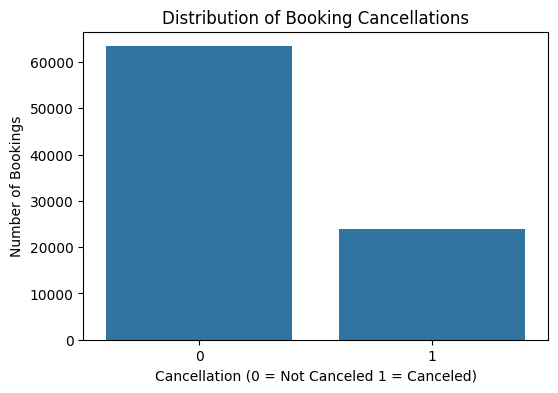

In [ ]:
#DISTRIBUTION OF BOOKING CANCELLATIONS
plt.figure(figsize=(6,4))

sns.countplot(x='is_canceled', data=df)
plt.title("Distribution of Booking Cancellations")
plt.xlabel("Cancellation (0 = Not Canceled 1 = Canceled)")
plt.ylabel("Number of Bookings")

plt.show()

The plot presents that cancellations are fewer than the completed bookings. Still, the number of cancellations is significant and its factors require further analysis.

Secondly, the relation of lead time and booking cancellations is investigated to examine if bookings made in advance have a strong association with cancellation.

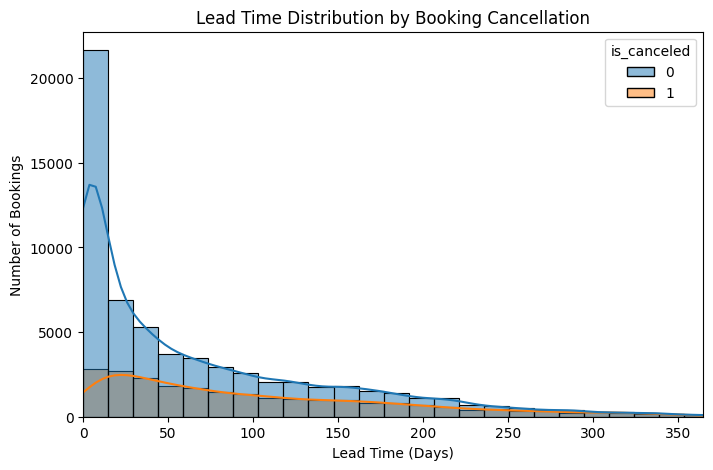

In [ ]:
#DISTRIBUTION AND COMPARISON OF BOOKING CANCELLATIONS ACROSS A LEAD TIME OF ONE YEAR
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='lead_time', hue='is_canceled', bins=50, kde=True)

plt.xlim(0,365)

plt.title("Lead Time Distribution by Booking Cancellation")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")

plt.show()

This distribution suggests that bookings are generally made in short lead times. At higher lead times the number of cancellations increases which indicates that reservations made in advance of more than a month, may have a higher chance of being canceled.

Next, in order to identify the seasonal patterns of the hotels, the distribution of bookings across each month is analysed.

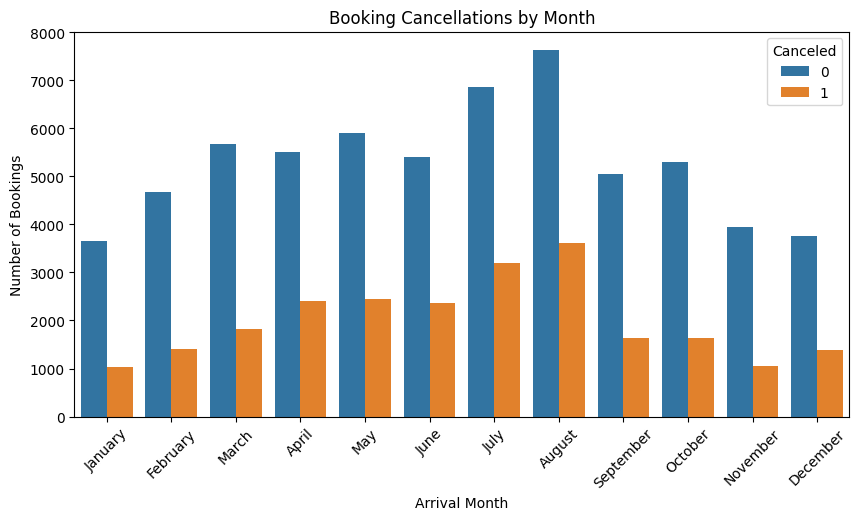

In [ ]:
#SEASONAL DISTRIBUTION OF BOOKINGS AND CANCELLATIONS ACROSS ALL MONTHS
plt.figure(figsize=(10,5))

sns.countplot(x='arrival_date_month', hue='is_canceled', data=df,
              order=['January','February','March','April','May','June','July','August','September','October','November','December'])

plt.title("Booking Cancellations by Month")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.legend(title="Canceled")

plt.xticks(rotation=45)
plt.show()

The plot suggests that summer months have the highest bookings, especially July and August. The cancellation amounts appear to follow a logical analogy to the bookings made with August having the highest cancellation number as a result of its high booking amount.

Furthermore, it is important to identify whether a hotel type influences a rate of cancellations. Thus, this step compares cancellation patterns to the two hotel categories.

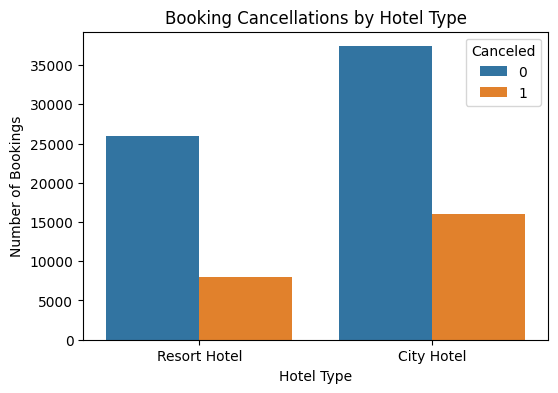

In [ ]:
#COMPARISON OF BOOKINGS AND CANCELLATIONS ACROSS HOTEL TYPES
plt.figure(figsize=(6,4))
sns.countplot(x='hotel', hue='is_canceled', data=df)

plt.title("Booking Cancellations by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Canceled")

plt.show()

This plot indicates that the City Hotel has a higher number of bookings which results in a higher number of cancellations. Therefore, high cancellation appears to correlate with booking volume rather than hotel type.

Additionally, the following analysis examines the relationship between deposit types with booking cancellations to identify if financial commitment affects customer cancellation behavior.

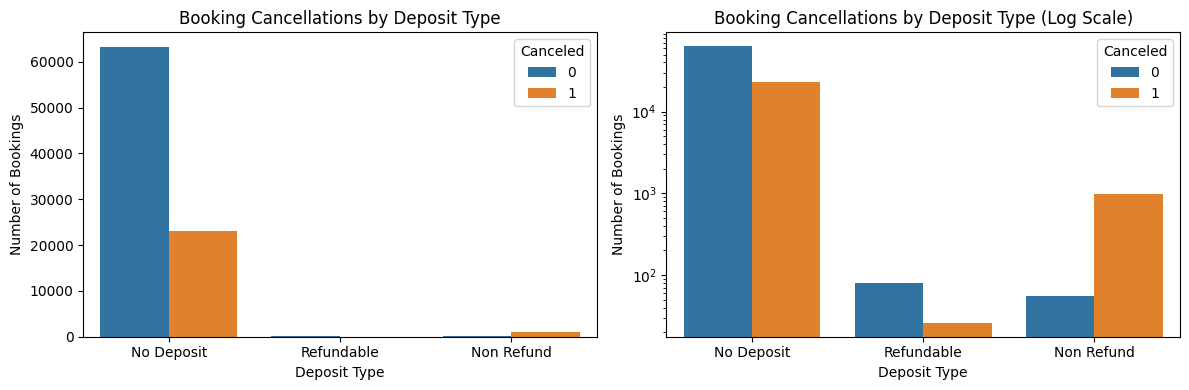

In [ ]:
#VISUALISATIONS FOR COMPARISON OF DEPOSIT TYPES AND BOOKING CANCELLATIONS
fig, axes = plt.subplots(1, 2, figsize=(12,4))

#BOOKING VOLUMES AND CANCELLATIONS BY DEPOSIT TYPE USING A STANDARD SCALE
sns.countplot(x='deposit_type', hue='is_canceled', data=df, ax=axes[0])

axes[0].set_title("Booking Cancellations by Deposit Type")
axes[0].set_xlabel("Deposit Type")
axes[0].set_ylabel("Number of Bookings")
axes[0].legend(title="Canceled")

#BOOKING VOLUMES AND CANCELLATIONS BY DEPOSIT TYPE USING A LOGARITHMIC SCALE
sns.countplot(x='deposit_type', hue='is_canceled', data=df, ax=axes[1])

axes[1].set_yscale('log')
axes[1].set_title("Booking Cancellations by Deposit Type (Log Scale)")
axes[1].set_xlabel("Deposit Type")
axes[1].set_ylabel("Number of Bookings")
axes[1].legend(title="Canceled")

plt.tight_layout()
plt.show()

The plots show that most bookings are made without financial commitments, which influence the highest amount of cancellations. No refund bookings are less frequently completed and show a high number of cancellations compared to the refundable deposit type. Thus, deposit policies might influence cancellation behavior.

Because the number of refundable and non-refundable deposits is far smaller, the logarithmic scale plot allows a comparison that would not be clear with the linear scale plot alone.

The findings from EDA show that lead time, seasonal booking patterns and deposit policies are some of the strongest factors associated with booking cancellations.  Based on these results, predictive modelling can be applied to analyse these relationships and evaluate their impact on booking cancellations prediction.

##Analytics Techniques and Modelling

In order for the machine learning models to be trained, the dataset needs to be prepared accordingly. In this step variables that could cause data leakage are removed while categorical variables are encoded into numerical form and the data is split into training and testing sets for the models.

In [ ]:
from sklearn.model_selection import train_test_split #IMPORT FOR TRAINING AND TESTING SPLIT
from sklearn.preprocessing import StandardScaler #IMPORT FOR NUMERICAL VARIABLE SCALING
import pandas as pd

#COPY OF THE DATASET FOR MODELLING
df_model = df.copy()

#REMOVAL OF VARIABLES THAT CAN CAUSE POSSIBLE DATA LEAKAGE OR ARE IRRELEVANT
columns_to_drop = [ 'reservation_status', 'reservation_status_date', 'company', 'agent' ]
df_model = df_model.drop(columns=columns_to_drop, errors='ignore')

#ENCODING CATEGORICAL VARIABLES
df_model = pd.get_dummies(df_model, drop_first=True)

#DEFINITION OF FEATURES (x) AND TARGET (y)
X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

#TRAINING AND TESTING SPLIT (80% TRAINING - 20% TESTING)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

#FEATURE SCALING TRANSFORMATION
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#CHECKS FOR TARGET VARIABLE DISTRIBUTION AND CLASS BALANCE
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training target distribution:
is_canceled
0    0.725
1    0.275
Name: proportion, dtype: float64

Test target distribution:
is_canceled
0    0.725
1    0.275
Name: proportion, dtype: float64


The dataset was split into training and testing subsets so the machine learning models are able to learn patterns from the training data and be evaluated on testing data.

Feature scaling was applied so that features with larger value ranges do not overshadow those with smaller ranges. This ensures that dataset features are on the same scale for reliable results.

Based on the output, the identical distribution values in the training and testing sets confirm that class balance was maintained after the split. Therefore, the models can be safely trained and evaluated on the data.

####Random Forest

Since the target of analysis is classification, a Random Forest classifier is implemented to predict hotel booking cancellations because of its ability to capture data patterns, interactions between variables and form predictions using results of multiple decision trees.

Random Forest Performance
Accuracy: 0.84
Precision: 0.77
Recall: 0.62
F1-Score: 0.68


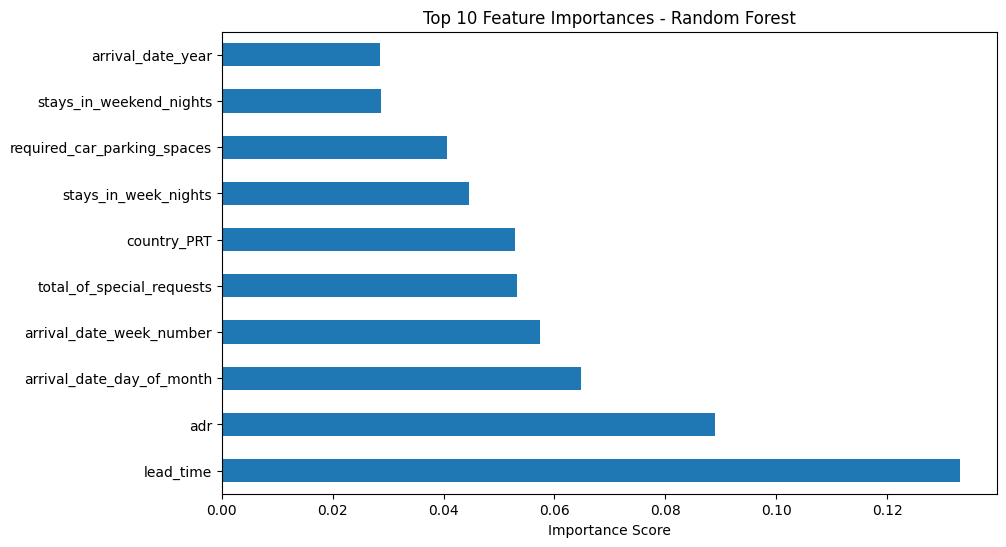

In [ ]:
from sklearn.ensemble import RandomForestClassifier #RANDOM FOREST CLASSIFIER FOR CLASSIFICATION MODELLING
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc #PERFORMANCE METRICS FOR RESULT EVALUATION
import pandas as pd #IMPORT FOR FEATURE IMPORTANCE PROCESSING
import matplotlib.pyplot as plt #IMPORT FOR DATA VISUALISATION AND PLOTS

#INITIALIZATION OF THE RANDOM FOREST MODEL
rf_model = RandomForestClassifier(
    n_estimators=200, #NUMBER OF DECISION TREES IN THE FOREST
    max_depth=None, #ALLOW TREES TO GROW FULLY UNTIL SPLITS CANNOT BE MADE
    random_state=42, #RANDOM SEED FOR REPRODUCIBILITY
    class_weight='balanced' #WEIGHTS FOR CLASS IMBALANCE IN BOOKINGS
)

#TRAINING OF THE MODEL
rf_model.fit(X_train, y_train)

#PROBABILITY PREDICTION
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

#CLASSIFICATION THRESHOLD
threshold = 0.5

#CONVERSION OF THE PREDICTED PROBABILITIES INTO A BINARY CLASS USING THE THRESHOLD
y_pred_adjusted_rf = (y_prob_rf >= threshold).astype(int)

#CALCULATION OF PERFORMANCE METRICS
accuracy_rf = accuracy_score(y_test, y_pred_adjusted_rf)
precision_rf = precision_score(y_test, y_pred_adjusted_rf)
recall_rf = recall_score(y_test, y_pred_adjusted_rf)
f1_rf = f1_score(y_test, y_pred_adjusted_rf)

#MODEL RESULTS
print("Random Forest Performance")
print(f"Accuracy: {accuracy_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print(f"F1-Score: {f1_rf:.2f}")

#COMPUTATION AND VISUALISATION OF THE TOP 10 FEATURES IN THE MODEL
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top_features = feature_importance.head(10)
plt.figure(figsize=(10,6))
top_features.plot(kind='barh')
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.show()

Based on the results, the model achieved an accuracy of 84. Its performance appears strong overall in the identification of booking cancellations. The feature importance graph reveals that *lead_time*, *adr*, *arrival_date_day_of_month* and *arrival_date_week_number* are the most influential predictors used by the model. This result suggests that bookings in advance, price of reservation as well as timing of stay, influence cancellations significantly.

####Logistic Regression

As a baseline classification model, Logistic Regression is implemented next for its simplicity and interpretability in binary classification problems. The model allows for the relationship between predictor variables and booking cancellations to be examined by estimating the contribution of each feature to the cancellation probability.

Logistic Regression Performance
Accuracy: 0.75
Precision: 0.53
Recall: 0.80
F1-Score: 0.64


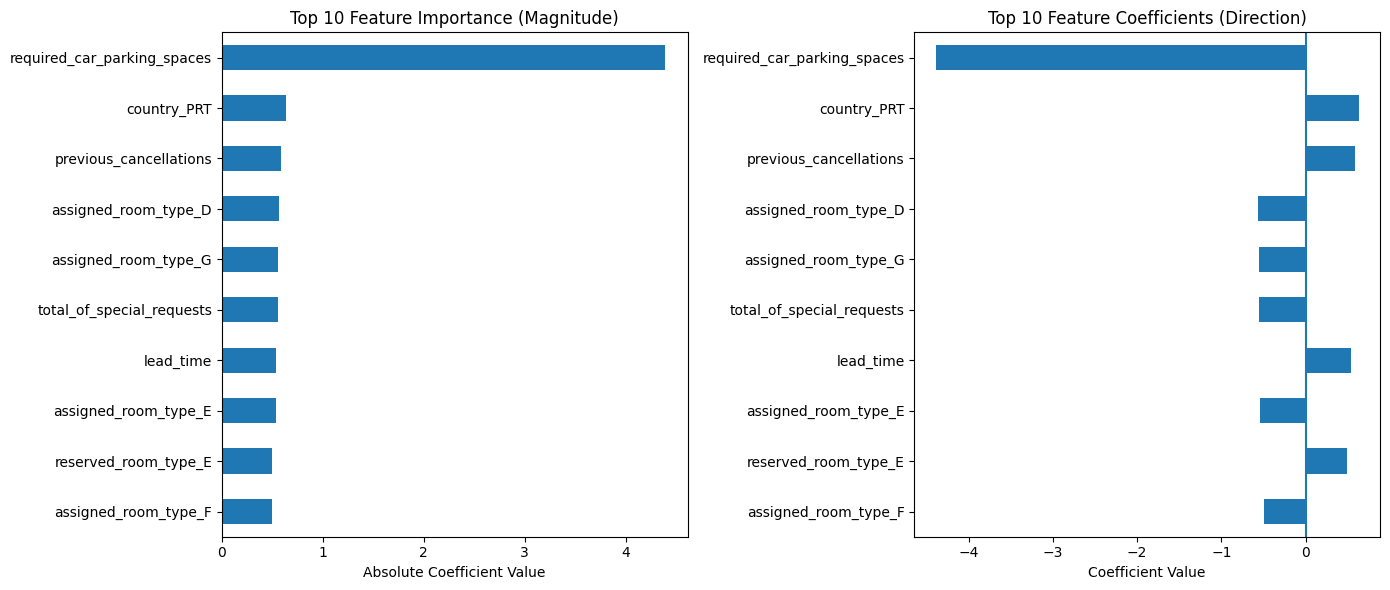

In [ ]:
from sklearn.linear_model import LogisticRegression #LOGISTIC REGRESSION MODEL FOR BINARY CLASSIFICATION
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #PERFORMANCE METRICS FOR MODEL EVALUATION
import pandas as pd #IMPORT FOR FEATURE COEFFICIENT PROCESSING
import matplotlib.pyplot as plt #IMPORT FOR DATA VISUALISATION AND PLOTS

#INITIALIZATION OF THE LOGISTIC REGRESSION MODEL
log_model = LogisticRegression(
    max_iter=1000, #INCREASE OF MAXIMUM ITERATIONS TO ENSURE MODEL CONVERGENCE
    random_state=42, #RANDOM SEED FOR REPRODUCIBILITY
    class_weight='balanced', #HANDLE CLASS IMBALANCE IN THE TARGET VARIABLE
    solver='lbfgs', #SOLVER FOR STANDARD DATASETS
)

#TRAINING OF THE MODEL
log_model.fit(X_train_scaled, y_train)

#PROBABILITY PREDICTION
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

#CLASSIFICATION THRESHOLD
threshold = 0.5

#CONVERT PREDICTED PROBABILITIES INTO BINARY CLASS PREDICTIONS USING THE THRESHOLD
y_pred_log = (y_prob_log >= threshold).astype(int)

#CALCULATION OF PERFORMANCE METRICS
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

#MODEL RESULTS
print("Logistic Regression Performance")
print(f"Accuracy: {accuracy_log:.2f}")
print(f"Precision: {precision_log:.2f}")
print(f"Recall: {recall_log:.2f}")
print(f"F1-Score: {f1_log:.2f}")

#COMPUTATION AND VISUALISATION OF THE TOP 10 MOST IMPORTANT FEATURES IN THE MODEL
coefficients = pd.Series( log_model.coef_[0], index=X_train.columns)

#TOP FEATURES BY MAGNITUDE
top_features_abs = coefficients.abs().sort_values(ascending=False).head(10)

#ORIGINAL COEFFICIENTS FOR THE SAME FEATURES
top_features_signed = coefficients[top_features_abs.index]
top_features_signed = top_features_signed.loc[top_features_abs.index]

#VISUAL ALIGNMENT FOR BOTH VISUALIZATIONS
top_features_abs_sorted = top_features_abs.sort_values()
top_features_signed_sorted = top_features_signed.loc[top_features_abs_sorted.index]

#PLOT CREATION
fig, axes = plt.subplots(1, 2, figsize=(14,6))

#MAGNITUDE PLOT
top_features_abs_sorted.plot(kind='barh', ax=axes[0])
axes[0].set_title("Top 10 Feature Importance (Magnitude)")
axes[0].set_xlabel("Absolute Coefficient Value")

#DIRECTION PLOT
top_features_signed_sorted.plot(kind='barh', ax=axes[1])
axes[1].set_title("Top 10 Feature Coefficients (Direction)")
axes[1].set_xlabel("Coefficient Value")
axes[1].axvline(0)

plt.tight_layout()
plt.show()

The results indicate that the Logistic Regression model cannot capture the non-linear patterns of the dataset, even though it achieved a high recall. The plots of the top features for this model display each feature's impact in magnitude and in the direction (positive or negative).

The direction plot provides useful insights into customer behavior even with the model's moderate performance. Based on the graph, customers with previous cancellations or bookings made further in advance are more likely to cancel their booking while those in need of facilities such as car parking are significantly more committed.

####Histogram Gradient Boosting

The final model used to investigate influential features is Gradient Boosting, chosen for its ability to capture complex and non-linear relationships in the data by building models in stages where each new model improves prediction accuracy. For computational efficiency, performance and better adherence to the large dataset, the Histogram Gradient Boosting variation is used.

Gradient Boosting Performance
Accuracy: 0.83
Precision: 0.68
Recall: 0.74
F1-Score: 0.71


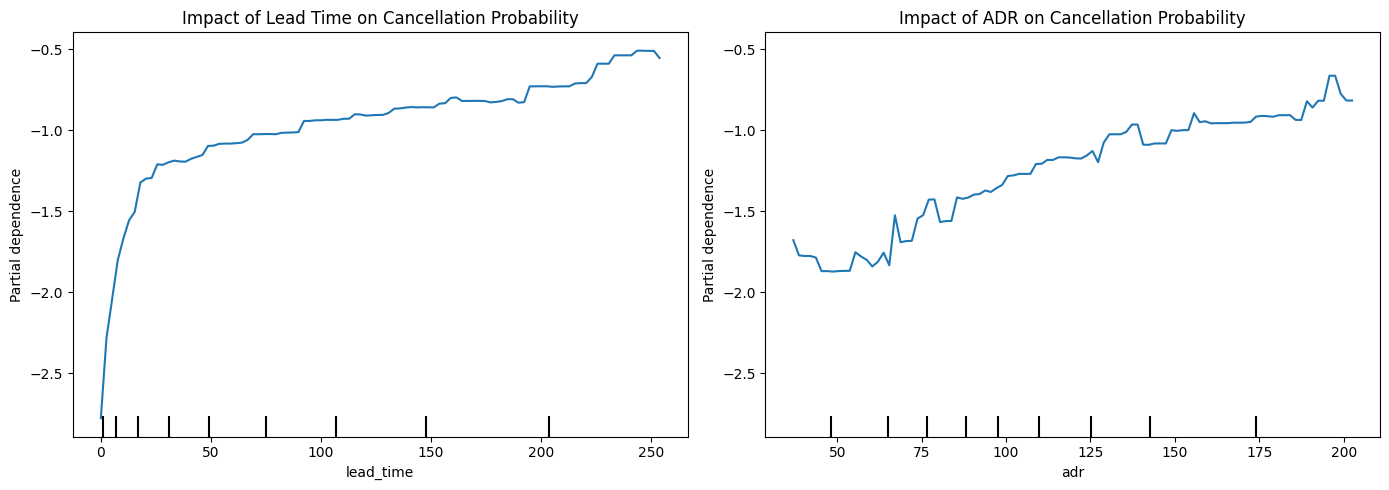

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier #IMPORT OF THE MODEL VARIATION FOR LARGE DATASETS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #PERFORMANCE METRICS FOR MODEL EVALUATION
from sklearn.inspection import PartialDependenceDisplay #IMPORT TO VISUALIZE HOW FEATURES AFFECT MODEL PREDICTIONS
import pandas as pd #IMPORT FOR DATA HANDLING AND PROCESSING
import matplotlib.pyplot as plt #IMPORT FOR DATA VISUALISATION AND PLOTS

#INITIALIZATION OF THE HISTOGRAM GRADIENT BOOSTING MODEL
gb_model = HistGradientBoostingClassifier(
    max_iter=500,           #BOOSTING ITERATIONS
    max_depth=4,            #MAXIMUM DEPTH OF EACH TREE
    random_state=42,        #RANDOM SEED FOR REPRODUCIBILITY
    class_weight= {0: 1.0, 1: 1.55} #CLASS IMBALANCE HANDLING SPECIFIC TO THE MODEL (MORE WEIGHT TO CANCELLATIONS)
    )

#TRAINING OF THE MODEL
gb_model.fit(X_train, y_train)

#PROBABILITY PREDICTION
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

#CLASSIFICATION THRESHOLD
threshold = 0.5

#CONVERSION OF PROBABILITIES TO BINARY PREDICTIONS
y_pred_gb = (y_prob_gb >= threshold).astype(int)

#CALCULATION OF PERFORMANCE METRICS
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

#MODEL RESULTS
print("Gradient Boosting Performance")
print(f"Accuracy: {accuracy_gb:.2f}")
print(f"Precision: {precision_gb:.2f}")
print(f"Recall: {recall_gb:.2f}")
print(f"F1-Score: {f1_gb:.2f}")

#PARTIAL DEPENDENCE PLOTS TO SHOW HOW KEY FEATURES AFFECT THE MODEL'S PREDICTION OF CANCELLATION
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

PartialDependenceDisplay.from_estimator( gb_model, X_test, ['lead_time', 'adr'], ax=ax)
ax[0].set_title("Impact of Lead Time on Cancellation Probability")
ax[1].set_title("Impact of ADR on Cancellation Probability")

plt.tight_layout()
plt.show()

The Histogram Gradient Boosting model presents a strong overall performance with an accuracy of 83% and a high F1-score which indicates the model's balance on precision and recall. Since the method of built-in feature importance can be biased on this model, partial dependence plots were used to examine how the previously identified influential features impact the model’s predictions.

Based on the plots, lead time and ADR are investigated as to their relationship with cancellations.

Lead time appears to have a strong relationship with the partial dependence which indicates that bookings made further in advance are more likely to be cancelled. Similarly, ADR has an upward trend with some fluctuations representing differences in customer behavior across price levels. Nevertheless, the upward trend suggests that expensive bookings are more likely to be cancelled.

The results of the plots support that these two features influence hotel booking cancellations and are effectively captured by the model.

### Model Comparison

In order to further evaluate the effectiveness of the models, a comparison is conducted using each model's performance scores. This aids in identifying which model is most suitable for booking cancellations prediction and for each of their strengths and weaknesses to be highlighted.

In addition to the model comparison table, confusion matrices are implemented to provide a detailed visualization of correct and incorrect predictions made by each model.



,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.84,0.77,0.62,0.68
1,Logistic Regression,0.75,0.53,0.80,0.64
2,Histogram Gradient Boosting,0.83,0.68,0.74,0.71


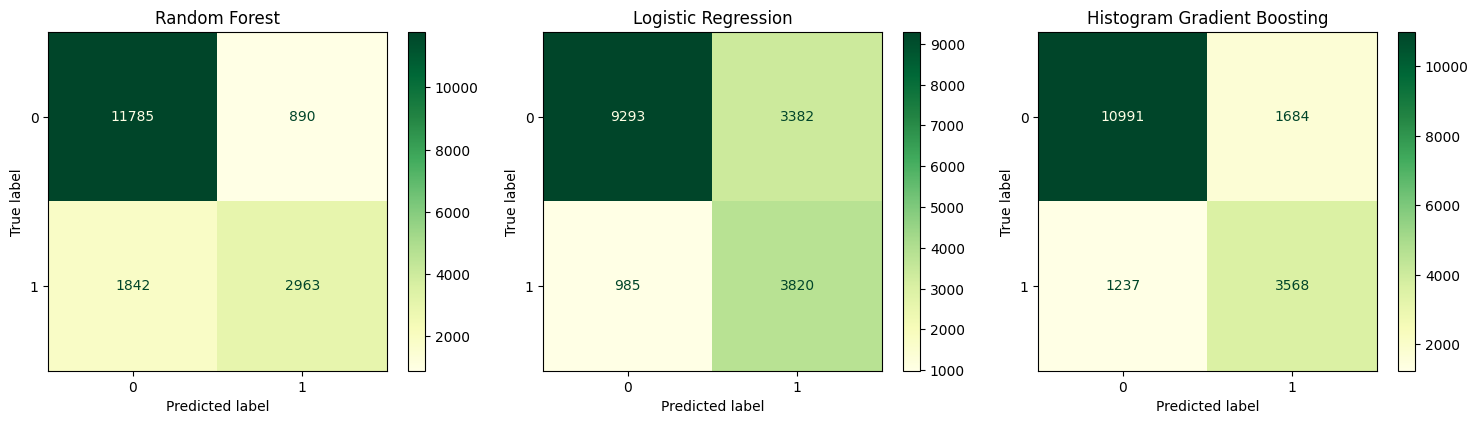

In [ ]:
#MODEL COMPARISON TABLE
from IPython.display import display
import pandas as pd

#USE OF PREVIOUS MODEL PERFORMANCE METRICS
results = {
    "Model": ["Random Forest", "Logistic Regression", "Histogram Gradient Boosting"],
    "Accuracy": [accuracy_rf, accuracy_log, accuracy_gb],
    "Precision": [precision_rf, precision_log, precision_gb],
    "Recall": [recall_rf, recall_log, recall_gb],
    "F1 Score": [f1_rf, f1_log, f1_gb]}

#RESULTS CONVERSION INTO A DATAFRAME
results_df = pd.DataFrame(results)

#DISPLAY TABLE
display(
    results_df.style \
    .format({
        "Accuracy": "{:.2f}",
        "Precision": "{:.2f}",
        "Recall": "{:.2f}",
        "F1 Score": "{:.2f}"
    }) \
    .highlight_max(axis=0, color='rgba(144, 238, 144, 0.3)')) #HIGHLIGHT OF THE BEST VALUE (MAX) IN EACH COLUMN TO IDENTIFY BEST PERFORMANCE

#CONFUSION MATRICES
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #IMPORT FOR COMPUTING AND VISUALIZING CONFUSION MATRICES
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = {
    "Random Forest": y_pred_adjusted_rf,
    "Logistic Regression": y_pred_log,
    "Histogram Gradient Boosting": y_pred_gb}

#LOOP FOR EACH MODEL TO PLOT ITS CONFUSION MATRIX
for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="YlGn")
    ax.set_title(name)

plt.tight_layout()
plt.show()

Consistently to previous visualizations, in the confusion matrices, 0 represents a booking that was not canceled, while 1 represents a canceled booking.

The confusion matrices are used to compare predicted and actual outcomes where true negatives (top left) and true positives (bottom right) represent the correct predictions while false positives (top right) and false negatives (bottom left) the places where the model made error.

The Random Forest model achieved the highest precision (0.77) and overall accuracy (0.84) which suggests that its predictions are more reliable in the identification of cancellations. This is also verified by its confusion matrix that shows a low number of false positives (top right). Its low recall (0.62) indicates that a proportion of some true cancellations fails to be identified.

The Logistic Regression model had the highest recall (0.80) which suggested that it was effective in identifying actual cancellations. This is also shown in the confusion matrix where the false negatives (bottom left) are the lowest among the models. However, the low precision (0.53) indicates that it also predicts booking cancellations that are not actually canceled.

The Histogram Gradient Boosting model appears to be the most stable with the highest F1 score (0.71) implying high balance between precision and recall. Its confusion matrix appears more even in terms of distribution of errors which shows that it was good at identifying cancellations and avoiding incorrect predictions.

Overall, while the Random Forest has higher performance metrics, the Histogram Gradient Boosting model can be considered the most efficient and trustworthy in the prediction of cancellations based on its balanced performance.


###Conclusion

The final results cover the analytical objectives by implementing machine learning models to predict cancellation behavior and visualizing variables that influence the likelihood of booking cancellations. Each visualization included an interpretation as to customer or variable behavior which can support hotel management in gathering insights as to how cancellation-related losses can be reduced.

##Critical Reflection

Ultimately, the analysis solution aligns with the data and provides consistent results. However, even though the behavior of the dataset features is logical, the relationships between features such as lead time or deposit type may not fully adhere in real-world scenarios where customer behavior shifts according to additional factors like economic conditions.

Additionally, the data provided relates to hotel types and structured booking facilities. This excludes extra variables that cannot be taken into account from this dataset like competitor activity, able to generate pricing strategies that might have a significant impact in booking cancelaltions. As a result, predictive performance can partially aid and not form a complete or competitive business plan.

For model fairness, consistency and reproducibility, a single train and test split was used with a limited number of advanced techniques specific for each model. For a thorough evaluation, especially in the case of supplementary variables, additional techniques such as cross-validation might ensure more trustworthy model results.

Nevertheless, over-reliance on automated predictions should be avoided since it can lead to weak or harmful business decisions. Regarding ethical considerations, the data used did not include any personally identifiable information which is validated in the dataset's source.
